<a href="https://colab.research.google.com/github/theboogeyman81/for_deep_learning/blob/main/HandWritten_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import pickle

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [4]:
print("\n📦 Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()


📦 Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [6]:
print("\n🔧 Normalizing data...")
X_train = X_train / 255.0
X_test = X_test / 255.0


🔧 Normalizing data...


In [ ]:
X_train = X_train/255
X_test = X_test/255


📊 Visualizing sample digits...
✅ Saved sample_digits.png


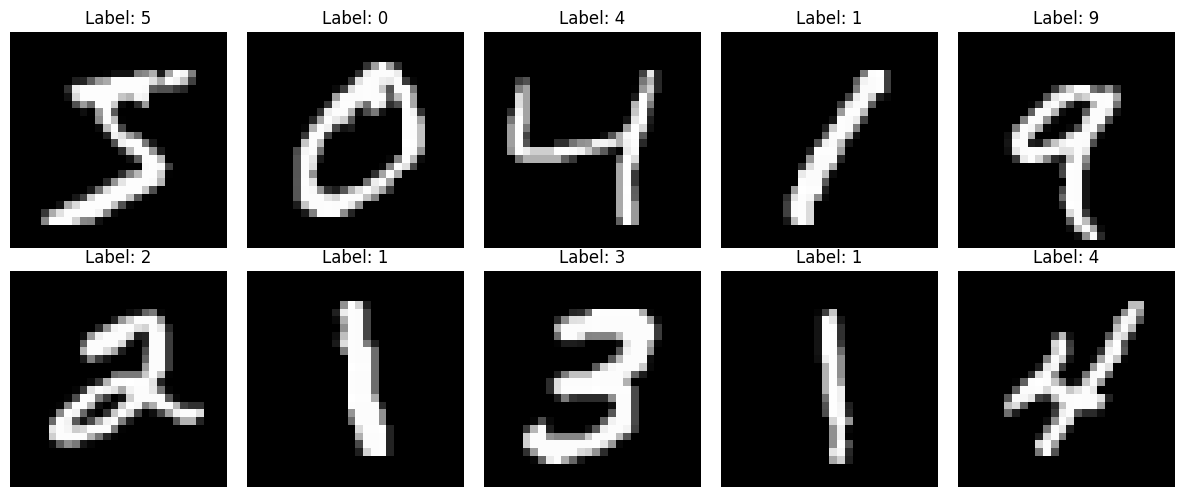

In [7]:
print("\n📊 Visualizing sample digits...")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_digits.png', dpi=150, bbox_inches='tight')
print("✅ Saved sample_digits.png")

In [9]:
print("\n🏗️ Building improved model...")
model = Sequential([
    # Input layer - Flatten 28x28 images to 784
    Flatten(input_shape=(28, 28)),

    # First hidden layer
    Dense(512, activation='relu', name='dense_1'),
    BatchNormalization(name='batch_norm_1'),
    Dropout(0.3, name='dropout_1'),

    # Second hidden layer
    Dense(256, activation='relu', name='dense_2'),
    BatchNormalization(name='batch_norm_2'),
    Dropout(0.3, name='dropout_2'),

    # Third hidden layer
    Dense(128, activation='relu', name='dense_3'),
    BatchNormalization(name='batch_norm_3'),
    Dropout(0.2, name='dropout_3'),

    # Output layer - 10 classes (digits 0-9)
    Dense(10, activation='softmax', name='output_layer')
], name='MNIST_MLP_Improved')


🏗️ Building improved model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.summary()

Model: "MNIST_MLP_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)


In [12]:
callbacks = [
    # Early stopping - stop if validation loss doesn't improve
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Model checkpoint - save best model
    ModelCheckpoint(
        'best_mnist_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # Reduce learning rate when plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-7
    )
]

In [13]:
print("\n🚀 Training model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,  # Will stop early if needed
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


🚀 Training model...
Epoch 1/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8340 - loss: 0.5398
Epoch 1: val_accuracy improved from -inf to 0.96700, saving model to best_mnist_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8343 - loss: 0.5387 - val_accuracy: 0.9670 - val_loss: 0.1075 - learning_rate: 0.0010
Epoch 2/30
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9538 - loss: 0.1465
Epoch 2: val_accuracy improved from 0.96700 to 0.97750, saving model to best_mnist_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9538 - loss: 0.1465 - val_accuracy: 0.9775 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 3/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9636 - loss: 0.1156
Epoch 3: val_accuracy improved from 0.97750 to 0.97850, saving model to best_mnist_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9636 - loss: 0.1156 - val_accuracy: 0.9785 - val_loss: 0.0704 - learning_rate: 0.0010
Epoch 4/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9728 - loss: 0.0888
Epoch 4: val_accuracy did not improve from 0.97850
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9728 - loss: 0.0888 - val_accuracy: 0.9780 - val_loss: 0.0766 - learning_rate: 0.0010
Epoch 5/30
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9750 - loss: 0.0816
Epoch 5: val_accuracy improved from 0.97850 to 0.97933, saving model to best_mnist_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9749 - loss: 0.0816 - val_accuracy: 0.9793 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 6/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9769 - loss: 0.0722
Epoch 6: val_accuracy improved from 0.97933 to 0.98167, saving model to best_mnist_model.h5


...

422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9817 - loss: 0.0539 - val_accuracy: 0.9832 - val_loss: 0.0610 - learning_rate: 0.0010
Epoch 10/30
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9841 - loss: 0.0491
Epoch 10: val_accuracy did not improve from 0.98317
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9841 - loss: 0.0491 - val_accuracy: 0.9820 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 11/30
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9841 - loss: 0.0493
Epoch 11: val_accuracy did not improve from 0.98317
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9841 - loss: 0.0493 - val_accuracy: 0.9830 - val_loss: 0.0619 - learning_rate: 0.0010
Epoch 12/30
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9852 - loss: 0.0459
Epoch 12: val_accuracy did not improve from 0.98317
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9852 - loss: 0.0459 - val_accuracy: 0.9832 - val_loss: 0.0594 - learning_rate: 0.0010
Epoch 13/3

422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9861 - loss: 0.0428 - val_accuracy: 0.9847 - val_loss: 0.0580 - learning_rate: 0.0010
Epoch 14/30
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9879 - loss: 0.0386
Epoch 14: val_accuracy improved from 0.98467 to 0.98500, saving model to best_mnist_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9879 - loss: 0.0386 - val_accuracy: 0.9850 - val_loss: 0.0563 - learning_rate: 0.0010
Epoch 15/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9879 - loss: 0.0382
Epoch 15: val_accuracy improved from 0.98500 to 0.98617, saving model to best_mnist_model.h5


422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9879 - loss: 0.0382 - val_accuracy: 0.9862 - val_loss: 0.0551 - learning_rate: 0.0010
Epoch 16/30
419/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9888 - loss: 0.0328
Epoch 16: val_accuracy did not improve from 0.98617
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9888 - loss: 0.0328 - val_accuracy: 0.9838 - val_loss: 0.0527 - learning_rate: 0.0010
Epoch 17/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9867 - loss: 0.0371
Epoch 17: val_accuracy did not improve from 0.98617
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9867 - loss: 0.0371 - val_accuracy: 0.9838 - val_loss: 0.0600 - learning_rate: 0.0010
Epoch 18/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9890 - loss: 0.0336
Epoch 18: val_accuracy did not improve from 0.98617
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9890 - loss: 0.0336 - val_accuracy: 0.9840 - val_loss: 0.0627 - learning_rate: 0.0010
Epoch 19/30



Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9945 - loss: 0.0155 - val_accuracy: 0.9863 - val_loss: 0.0557 - learning_rate: 5.0000e-04
Epoch 24/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9950 - loss: 0.0142
Epoch 24: val_accuracy did not improve from 0.98633
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9950 - loss: 0.0142 - val_accuracy: 0.9858 - val_loss: 0.0582 - learning_rate: 2.5000e-04
Epoch 25/30
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9967 - loss: 0.0096
Epoch 25: val_accuracy did not improve from 0.98633
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9967 - loss: 0.0096 - val_accuracy: 0.9863 - val_loss: 0.0543 - learning_rate: 2.5000e-04
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 20.


In [14]:
print("\n📈 Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


📈 Evaluating on test set...
Test Loss: 0.0500
Test Accuracy: 0.9864 (98.64%)


In [15]:
print("\n🔮 Making predictions...")
y_prob = model.predict(X_test, verbose=0)
y_pred = y_prob.argmax(axis=-1)


🔮 Making predictions...


In [16]:
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000




🔥 Generating confusion matrix...
✅ Saved confusion_matrix.png


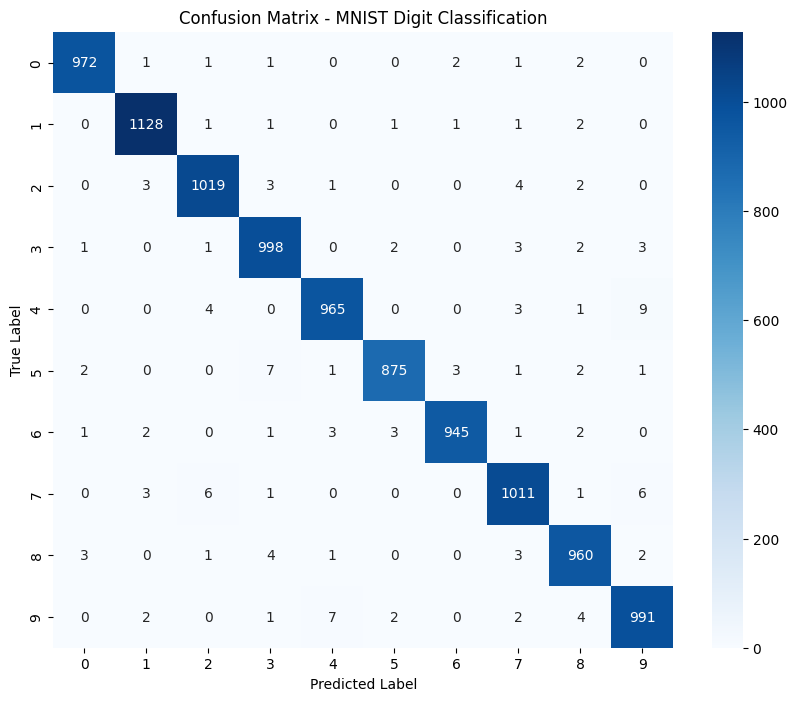

In [17]:
print("\n🔥 Generating confusion matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - MNIST Digit Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
print("✅ Saved confusion_matrix.png")


📉 Plotting training history...
✅ Saved training_history.png


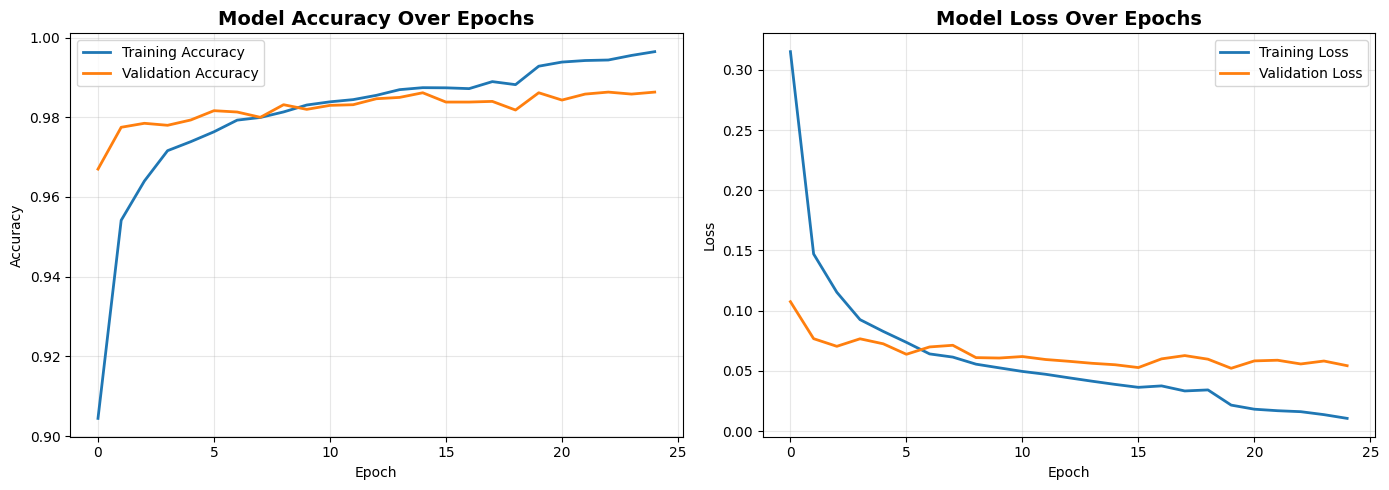

In [19]:
print("\n📉 Plotting training history...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
print("✅ Saved training_history.png")


🎯 Sample Predictions:
✅ Saved sample_predictions.png


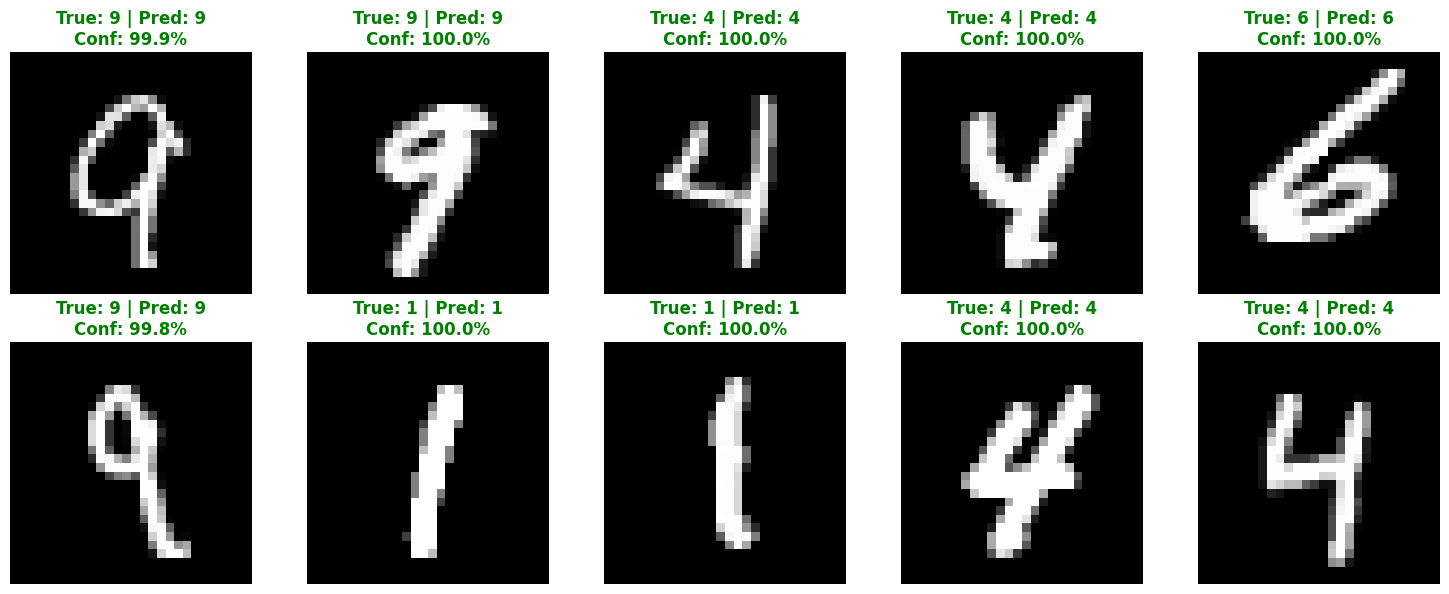

In [20]:
print("\n🎯 Sample Predictions:")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = np.random.choice(len(X_test), 10, replace=False)

for i, (ax, idx) in enumerate(zip(axes.flat, indices)):
    ax.imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    confidence = y_prob[idx][pred_label] * 100

    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label} | Pred: {pred_label}\nConf: {confidence:.1f}%",
                 color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
print("✅ Saved sample_predictions.png")

In [23]:
print("\n💾 Saving models...")

# 1. Save as Keras .h5 format (recommended for Keras/TensorFlow)
model.save('mnist_model_final.h5')
print("✅ Saved mnist_model_final.h5")

# 2. Save as SavedModel format (TensorFlow standard)
model.export('mnist_model_savedmodel')
print("✅ Saved mnist_model_savedmodel/")

# 3. Save model architecture and weights separately
model_json = model.to_json()
with open("mnist_model_architecture.json", "w") as json_file:
    json_file.write(model_json)
model.save_weights("mnist_model.weights.h5")
print("✅ Saved mnist_model_architecture.json and mnist_model.weights.h5")

# 4. Save preprocessing info and metadata as pickle
model_metadata = {
    'input_shape': (28, 28),
    'output_classes': 10,
    'normalization': 'divide_by_255',
    'class_names': list(range(10)),
    'test_accuracy': float(test_accuracy),
    'test_loss': float(test_loss),
    'training_epochs': len(history.history['loss']),
    'model_architecture': 'MLP with BatchNorm and Dropout'
}

with open('model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)
print("✅ Saved model_metadata.pkl")

# 5. Optional: Save entire model as pickle (not recommended but possible)
# Note: This is mainly for metadata. For neural networks, use .h5 or SavedModel
with open('model_info.pkl', 'wb') as f:
    pickle.dump({
        'metadata': model_metadata,
        'history': history.history
    }, f)
print("✅ Saved model_info.pkl")

print("\n" + "="*60)
print("🎉 MODEL TRAINING COMPLETE!")
print("="*60)
print(f"\n📊 Final Results:")
print(f"   • Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   • Test Loss: {test_loss:.4f}")
print(f"   • Total Epochs: {len(history.history['loss'])}")

print(f"\n📁 Saved Files:")
print(f"   • mnist_model_final.h5 (main model - use this for FastAPI)")
print(f"   • best_mnist_model.h5 (best checkpoint)")
print(f"   • mnist_model_savedmodel/ (TensorFlow format)")
print(f"   • model_metadata.pkl (preprocessing info)")
print(f"   • training_history.png (training plots)")
print(f"   • confusion_matrix.png (evaluation)")
print(f"   • sample_predictions.png (example outputs)")

print("\n💡 Next Steps:")
print("   1. Use 'mnist_model_final.h5' in your FastAPI backend")
print("   2. Load with: keras.models.load_model('mnist_model_final.h5')")
print("   3. Preprocess images: resize to 28x28, normalize to 0-1")
print("="*60)


💾 Saving models...
✅ Saved mnist_model_final.h5
Saved artifact at 'mnist_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor_1')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133268705637200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705637968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705638352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705638544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705638160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705637392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705637776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705637008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705639696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133268705639888: TensorSpec(sha